In [210]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [112]:
train_df=pd.read_csv("/content/drive/MyDrive/Datasets/Predicting Stellar Class_train.csv")

In [113]:
test_df=pd.read_csv("/content/drive/MyDrive/Datasets/Predicting Stellar Class_test.csv")

In [114]:
train_df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


In [115]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [116]:
Y_train=train_df["class"]

In [117]:
train_df=train_df.drop(columns=["class"],axis=1)

In [118]:
num_cols=train_df.select_dtypes(include=["int64","float64"]).columns

In [119]:
cat_cols=train_df.select_dtypes(include=["object"]).columns

In [120]:
num_cols

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift'], dtype='object')

In [121]:
cat_cols

Index(['spectral_type', 'galaxy_population'], dtype='object')

In [122]:
len(num_cols)+len(cat_cols)==len(train_df.columns)

True

In [123]:
encoder=OneHotEncoder(sparse_output=False)

In [124]:
train_encoded=encoder.fit_transform(train_df[cat_cols])

In [125]:
train_encoded

array([[0., 0., 1., 0., 0., 1.],
       [0., 0., 1., 0., 0., 1.],
       [0., 0., 0., 1., 1., 0.],
       ...,
       [0., 0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 1., 0.]])

In [126]:
train_encoded_cols=encoder.get_feature_names_out(cat_cols)

In [127]:
train_encoded_cols

array(['spectral_type_A/F', 'spectral_type_G/K', 'spectral_type_M',
       'spectral_type_O/B', 'galaxy_population_Blue_Cloud',
       'galaxy_population_Red_Sequence'], dtype=object)

In [128]:
train_encoded_df=pd.DataFrame(train_encoded,columns=train_encoded_cols,index=train_df.index)

In [129]:
train_encoded_df

,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...
577342,0.0,0.0,1.0,0.0,0.0,1.0
577343,0.0,0.0,1.0,0.0,0.0,1.0
577344,0.0,0.0,1.0,0.0,0.0,1.0
577345,0.0,1.0,0.0,0.0,1.0,0.0


In [130]:
scaler=StandardScaler()

In [131]:
train_df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud


In [132]:
train_scaled=scaler.fit_transform(train_df[num_cols])

In [133]:
train_scaled

array([[-1.73204781, -0.35205123, -0.25749954, ..., -0.07708444,
        -0.26514027, -0.38781024],
       [-1.73204181, -0.55721532,  0.55520808, ..., -1.36250957,
        -1.42309683, -0.69766825],
       [-1.73203581, -0.01895231,  0.71355799, ...,  0.76181928,
         0.95699611,  2.59315406],
       ...,
       [ 1.73203581, -1.34407632, -1.11773878, ..., -0.38393234,
        -0.52875443, -0.42810296],
       [ 1.73204181,  0.68312161,  1.52243812, ...,  0.98225074,
         1.53815557,  2.64819763],
       [ 1.73204781,  0.13525312, -1.22226041, ...,  0.9413798 ,
         0.917892  ,  0.46646487]])

In [134]:
train_scaled_df=pd.DataFrame(train_scaled,columns=num_cols,index=train_df.index)

In [135]:
X_train=pd.concat([train_scaled_df,train_encoded_df],axis=1)

In [136]:
X_train

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type_A/F,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Blue_Cloud,galaxy_population_Red_Sequence
0,-1.732048,-0.352051,-0.257500,1.501485,0.494750,0.239615,-0.077084,-0.265140,-0.387810,0.0,0.0,1.0,0.0,0.0,1.0
1,-1.732042,-0.557215,0.555208,-0.824235,-1.069503,-1.440665,-1.362510,-1.423097,-0.697668,0.0,0.0,1.0,0.0,0.0,1.0
2,-1.732036,-0.018952,0.713558,-0.697042,0.040021,0.733207,0.761819,0.956996,2.593154,0.0,0.0,0.0,1.0,1.0,0.0
3,-1.732030,0.459272,1.412031,0.427687,0.024207,-0.573122,-0.641276,-0.710811,-0.230890,0.0,0.0,1.0,0.0,0.0,1.0
4,-1.732024,-0.413335,-0.131608,-0.366065,-0.855282,-1.048151,-0.936335,-0.899384,-0.206617,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577342,1.732024,0.435592,-1.020990,-0.799351,-1.199200,-1.370379,-1.384996,-1.571470,-0.261226,0.0,0.0,1.0,0.0,0.0,1.0
577343,1.732030,0.439298,1.000060,0.640601,0.752970,0.445768,-0.125721,-0.059242,-0.079680,0.0,0.0,1.0,0.0,0.0,1.0
577344,1.732036,-1.344076,-1.117739,-0.246602,0.116174,-0.568142,-0.383932,-0.528754,-0.428103,0.0,0.0,1.0,0.0,0.0,1.0
577345,1.732042,0.683122,1.522438,-0.233902,0.342812,0.621460,0.982251,1.538156,2.648198,0.0,1.0,0.0,0.0,1.0,0.0


In [140]:
Y_train.value_counts()

,count
class,
0,377480
1,117143
2,82724


In [139]:
Y_train=Y_train.map({"GALAXY":0,"QSO":1,"STAR":2})

GALAXY:0,
QSO:1,
STAR:2

In [142]:
Y_train

,class
0,0
1,0
2,1
3,0
4,0
...,...
577342,0
577343,0
577344,0
577345,1


In [143]:
X_train.shape

(577347, 15)

In [144]:
test_df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population
0,577347,120.719779,23.924249,23.668066,21.951680,21.086183,20.180032,19.202124,0.429042,G/K,Red_Sequence
1,577348,219.414419,42.171651,24.902933,22.338822,20.732163,19.860330,19.687691,0.867305,M,Red_Sequence
2,577349,173.568731,-1.756400,19.427591,18.474633,17.551314,16.570674,16.176765,0.224234,G/K,Blue_Cloud
3,577350,184.903993,-1.411074,23.121029,21.526855,20.670159,20.417633,20.699095,0.066507,G/K,Red_Sequence
4,577351,222.487816,15.381403,25.094282,22.643981,21.123173,19.439500,19.094158,0.977218,M,Red_Sequence
...,...,...,...,...,...,...,...,...,...,...,...
247430,824777,248.013903,49.533434,21.563545,21.716868,21.670791,21.265478,21.558618,1.214520,A/F,Blue_Cloud
247431,824778,226.823885,52.635936,21.434441,21.075412,20.778300,20.962333,21.010822,1.004950,A/F,Blue_Cloud
247432,824779,232.879335,44.948125,23.294670,22.336583,20.121142,19.405430,18.744581,0.269394,M,Red_Sequence
247433,824780,351.396802,2.451824,20.882944,20.902010,20.222812,20.551737,20.278339,1.199392,G/K,Blue_Cloud


In [147]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247435 entries, 0 to 247434
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 247435 non-null  int64  
 1   alpha              247435 non-null  float64
 2   delta              247435 non-null  float64
 3   u                  247435 non-null  float64
 4   g                  247435 non-null  float64
 5   r                  247435 non-null  float64
 6   i                  247435 non-null  float64
 7   z                  247435 non-null  float64
 8   redshift           247435 non-null  float64
 9   spectral_type      247435 non-null  object 
 10  galaxy_population  247435 non-null  object 
dtypes: float64(8), int64(1), object(2)
memory usage: 20.8+ MB


In [150]:
num_cols_test=test_df.select_dtypes(include=["int64","float64"]).columns

In [151]:
cat_cols_test=test_df.select_dtypes(include=["object"]).columns

In [152]:
encoded_test=encoder.transform(test_df[cat_cols_test])

In [153]:
encoded_test

array([[0., 1., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 1.]])

In [154]:
encoded_test_cols=encoder.get_feature_names_out(cat_cols_test)

In [155]:
encoded_test_cols

array(['spectral_type_A/F', 'spectral_type_G/K', 'spectral_type_M',
       'spectral_type_O/B', 'galaxy_population_Blue_Cloud',
       'galaxy_population_Red_Sequence'], dtype=object)

In [157]:
encoded_test_df=pd.DataFrame(encoded_test,columns=encoded_test_cols,index=test_df.index)

In [159]:
encoded_test_df.columns==train_encoded_df.columns

array([ True,  True,  True,  True,  True,  True])

In [160]:
test_scaled=scaler.transform(test_df[num_cols_test])

In [161]:
test_scaled

array([[ 1.73205381, -0.63274196,  0.11036462, ...,  0.5070202 ,
         0.10161082, -0.36304676],
       [ 1.73205981,  0.392733  ,  1.07412462, ...,  0.30468459,
         0.40808463,  0.17797172],
       [ 1.73206581, -0.08362119, -1.2459919 , ..., -1.77730025,
        -1.8078998 , -0.61587455],
       ...,
       [ 3.21665421,  0.53263862,  1.22076765, ...,  0.01678335,
        -0.1871763 , -0.56012698],
       [ 3.21666021,  1.7640803 , -1.02372912, ...,  0.74226763,
         0.78088313,  0.58792128],
       [ 3.21666621,  0.11613327,  0.73993907, ...,  0.28778173,
         0.22623318, -0.22010924]])

In [162]:
test_scaled_df=pd.DataFrame(test_scaled,columns=num_cols_test,index=test_df.index)

In [163]:
test_scaled_df

,id,alpha,delta,u,g,r,i,z,redshift
0,1.732054,-0.632742,0.110365,0.607562,0.526007,0.681260,0.507020,0.101611,-0.363047
1,1.732060,0.392733,1.074125,1.219448,0.741634,0.466568,0.304685,0.408085,0.177972
2,1.732066,-0.083621,-1.245992,-1.493625,-1.410609,-1.462433,-1.777300,-1.807900,-0.615875
3,1.732072,0.034157,-1.227753,0.336501,0.289392,0.428966,0.657395,1.046451,-0.810583
4,1.732078,0.424667,-0.340837,1.314262,0.911599,0.703692,0.038346,0.033466,0.313655
...,...,...,...,...,...,...,...,...,...
247430,3.216642,0.689893,1.462947,-0.435244,0.395224,1.035791,1.193986,1.588954,0.606596
247431,3.216648,0.469720,1.626809,-0.499216,0.037951,0.494547,1.002129,1.243203,0.347890
247432,3.216654,0.532639,1.220768,0.422541,0.740388,0.096019,0.016783,-0.187176,-0.560127
247433,3.216660,1.764080,-1.023729,-0.772487,-0.058629,0.157676,0.742268,0.780883,0.587921


In [164]:
X_test=pd.concat([test_scaled_df,encoded_test_df],axis=1)

In [166]:
X_train.shape

(577347, 15)

In [167]:
X_test.shape

(247435, 15)

In [171]:
logistic_model=LogisticRegression(max_iter=500)

In [172]:
logistic_model.fit(X_train,Y_train)

LogisticRegression(max_iter=500)

In [173]:
train_score=logistic_model.score(X_train,Y_train)

In [174]:
print(f"Train Score of Logistic Regression Model is :{train_score}")

Train Score of Logistic Regression Model is :0.9268724008265393


In [175]:
logistic_predict=logistic_model.predict(X_test)

In [176]:
logistic_predict

array([0, 0, 0, ..., 0, 1, 0])

In [177]:
random_forest_model=RandomForestClassifier()

In [180]:
random_forest_model.fit(X_train,Y_train)

RandomForestClassifier()

In [181]:
random_forest_score=random_forest_model.score(X_train,Y_train)

In [182]:
print(f"Train Score of Random Forest Model is :{random_forest_score}")

Train Score of Random Forest Model is :0.9999930717575393


In [183]:
random_forest_predict=random_forest_model.predict(X_test)

In [188]:
random_forest_predict

array([0, 0, 0, ..., 0, 1, 0])

In [211]:
gradient_model=GradientBoostingClassifier()

In [212]:
gradient_model.fit(X_train,Y_train)

GradientBoostingClassifier()

In [213]:
gradient_train_score=gradient_model.score(X_train,Y_train)

In [214]:
print(f"Train Score of Gradient Boosting Model is :{gradient_train_score}")

Train Score of Gradient Boosting Model is :0.9545455332754825


In [215]:
import matplotlib.pyplot as plt

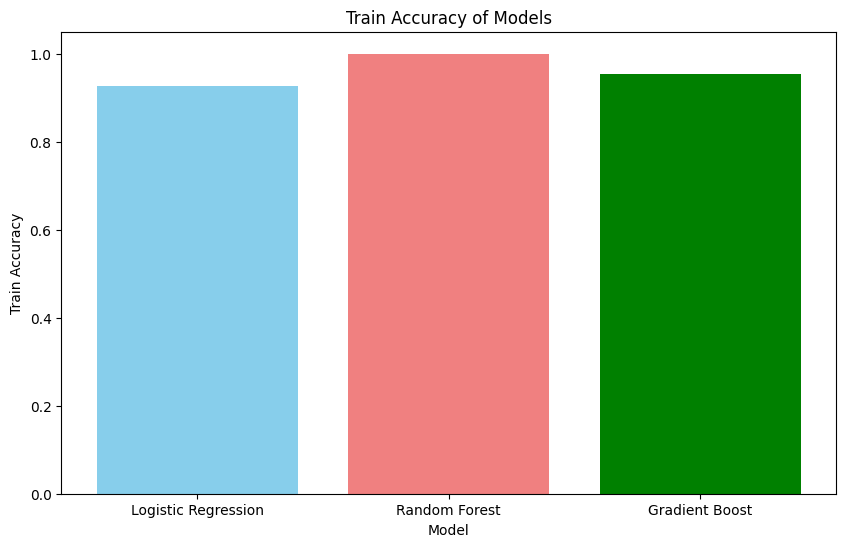

In [216]:
scores=[train_score,random_forest_score,gradient_train_score]
models=["Logistic Regression","Random Forest","Gradient Boost"]
plt.figure(figsize=(10,6))
plt.bar(models,scores,color=['skyblue', 'lightcoral',"green"])
plt.xlabel("Model")
plt.ylabel("Train Accuracy")
plt.title("Train Accuracy of Models")
plt.show()

In [221]:
result_df=pd.DataFrame({"ID":test_df["id"],"class":random_forest_predict})

In [225]:
result_df["class"].value_counts()

,count
class,
0,162283
1,50065
2,35087


In [226]:
result_df["class"]=result_df["class"].map({0:"GALAXY",1:"QSO",2:"STAR"})

In [227]:
result_df["class"].value_counts()

,count
class,
GALAXY,162283
QSO,50065
STAR,35087


In [228]:
result_df.to_csv("Stellar_Class_Submission.csv",index=False)